<a href="https://colab.research.google.com/github/Paulo123213/MineriaDatos/blob/PauloGuerra/prueba1mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Carga de Datos

En esta sección, cargamos el conjunto de datos `tl-calculated-delta-table.csv` en un DataFrame de pandas para su posterior análisis. Se carga dos veces para mantener una copia original (`df`) y otra para limpieza (`df_clean`).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('tl-calculated-delta-table.csv')

## 2. Limpieza y Preprocesamiento Inicial

Aquí realizamos las primeras etapas de limpieza del DataFrame `df_clean`.

*   **Eliminación de Columnas**: Se eliminan columnas que no son relevantes para el análisis actual o que ya se han verificado que tienen valores constantes o información duplicada (`vs`, `raw_eff`, `adjusted_eff`, `verified`).
*   **Normalización de Rangos**: La columna `tlrank` se normaliza convirtiendo los valores a minúsculas y eliminando espacios para asegurar consistencia.

In [3]:
df_clean = pd.read_csv('tl-calculated-delta-table.csv')

In [4]:
df_clean = df_clean.drop(columns=['vs', 'raw_eff', 'adjusted_eff', 'verified'])

In [5]:
df_clean['tlrank'] = df_clean['tlrank'].astype(str).str.strip().str.lower()

## 3. Mapeo de Rangos

Para facilitar el análisis numérico, la columna `tlrank` (que contiene rangos de texto como 'x', 'u', 's+', etc.) se mapea a valores numéricos enteros. Esto convierte una variable categórica ordinal en una numérica, permitiendo cálculos como correlaciones.

*   Se define un diccionario `rank_mapping` para asignar un valor numérico a cada rango.
*   Se crea una nueva columna `rank_num` en `df_clean` con los valores mapeados.

In [6]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8177602 entries, 0 to 8177601
Data columns (total 13 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   username      object 
 2   tlrank        object 
 3   apm           float64
 4   pps           float64
 5   raw_app       float64
 6   adjusted_app  float64
 7   tr            float64
 8   glicko        float64
 9   rd            int64  
 10  gamesplayed   int64  
 11  gameswon      int64  
 12  deltadate     object 
dtypes: float64(6), int64(3), object(4)
memory usage: 811.1+ MB
None


In [7]:
df_clean.head(10)

,id,username,tlrank,apm,pps,raw_app,adjusted_app,tr,glicko,rd,gamesplayed,gameswon,deltadate
0,5e484c3eadfab42c76f0af36,vince,x,139.63,3.44,0.676502,0.452287,24546.0,2553.0,85,31,26,2020-04-08 17:42:00
1,5e3f6ebe3dacc16dbc4dd6aa,doremy,x,116.71,2.79,0.697192,0.465930,24266.0,2419.0,71,100,86,2020-04-08 17:42:00
2,5e40825a4be6907ad7eab03d,sm999,u,128.92,3.32,0.647189,0.432719,24239.0,2409.0,72,72,64,2020-04-08 17:42:00
3,5e3d58e92445dd5207770ca5,wumbo,u,93.24,2.37,0.655696,0.438045,24213.0,2401.0,75,74,67,2020-04-08 17:42:00
4,5e4f0ad196a8426ec442746e,qmk,u,121.82,2.92,0.695320,0.464754,24137.0,2376.0,76,44,39,2020-04-08 17:42:00
5,5e40a2b74be6907ad7eab292,cheep,u,109.59,2.88,0.634201,0.423902,24012.0,2345.0,95,20,14,2020-04-08 17:42:00
6,5e697bbf77aba60f95fb38da,firestorm,u,119.78,2.94,0.679025,0.453900,23948.0,2320.0,70,64,49,2020-04-08 17:42:00
7,5e381f4c456244768a097502,zack101155,u,104.13,2.51,0.691434,0.462049,23638.0,2251.0,79,38,35,2020-04-08 17:42:00
8,5e436daf368a5d2489fbf848,star,u,107.18,2.74,0.651946,0.435760,23570.0,2243.0,99,24,24,2020-04-08 17:42:00
9,5e4db4eff5d51a6eb7ec0bb6,zerot,u,115.67,3.05,0.632077,0.422605,23563.0,2238.0,87,25,22,2020-04-08 17:42:00


## 3.1 Diccionario de Datos
## Aqui explicamos el significado de cada dato de la DF
| Columna        | Tipo de Dato | Descripción                                           |
| :------------- | :----------- | :---------------------------------------------------- |
| `id`           | `object`     |  `id del jugador`                                                     |
| `username`     | `object`     |         `Nombre del jugador`                                              |
| `tlrank`       | `object`     |     `Rango del jugador en la categoria de 1 vs 1`                                                  |
| `apm`          | `float64`    |   `Ataques por minuto `                                                    |
| `pps`          | `float64`    |    `Piezas por minuto`                                                   |
| `raw_app`      | `float64`    |       `Ataques por pieza siendo la cantidad de ataques realizados con una pieza`                                                |
| `adjusted_app` | `float64`    |       `Ataques por pieza promediado entre partidas`                                                |
| `tr`           | `float64`    |   `Rango del jugador`                                                    |
| `glicko`       | `float64`    |      `Representacion numerica del rango del jugador `                                                 |
| `rd`           | `int64`      |   `Rating deviaton `                                                    |
| `gamesplayed`  | `int64`      |    `Cantidad de juegos por el jugador`                                                   |
| `gameswon`     | `int64`      |     `Juegos ganados por el jugador`                                                        
| `rank_num`     | `float64`    | `Numero de ranking mundial` |

In [8]:
df_clean.isna().sum()

,0
id,0
username,0
tlrank,0
apm,0
pps,0
raw_app,0
adjusted_app,0
tr,0
glicko,0
rd,0


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8177602 entries, 0 to 8177601
Data columns (total 17 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   username      object 
 2   tlrank        object 
 3   apm           float64
 4   pps           float64
 5   vs            float64
 6   raw_eff       float64
 7   adjusted_eff  float64
 8   raw_app       float64
 9   adjusted_app  float64
 10  tr            float64
 11  glicko        float64
 12  rd            int64  
 13  gamesplayed   int64  
 14  gameswon      int64  
 15  verified      float64
 16  deltadate     object 
dtypes: float64(10), int64(3), object(4)
memory usage: 1.0+ GB
None


In [10]:
rank_mapping = {
    'x': 17, 'u': 16, 'ss': 15, 's+': 14, 's': 13, 's-': 12,
    'a+': 11, 'a': 10, 'a-': 9, 'b+': 8, 'b': 7, 'b-': 6,
    'c+': 5, 'c': 4, 'c-': 3, 'd+': 2, 'd': 1, 'z': 0
}
df_clean['rank_num'] = df_clean['tlrank'].map(rank_mapping)

## 4. Conversión de Tipos de Datos y Filtrado

Se asegura que las columnas clave para el análisis sean de tipo numérico. Cualquier valor que no pueda ser convertido se reemplaza por `NaN` (Not a Number) y luego se eliminan las filas que contienen estos `NaN` para tener un conjunto de datos limpio para el análisis estadístico.

In [11]:
cols_analisis = ['rank_num', 'apm', 'pps', 'raw_app', 'adjusted_app']
for col in cols_analisis:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [12]:
df_final = df_clean[cols_analisis].dropna()

## 5. Información y Muestreo de Datos Finales

Se muestra la cantidad de registros finales después de la limpieza y filtrado, así como las primeras filas del DataFrame `df_final`, para verificar la estructura y los tipos de datos de las columnas que se utilizarán en el análisis.

In [13]:
print(f"Registros listos para el análisis: {len(df_final)}")
print(df_final.head())

Registros listos para el análisis: 8177602
   rank_num     apm   pps   raw_app  adjusted_app
0        17  139.63  3.44  0.676502      0.452287
1        17  116.71  2.79  0.697192      0.465930
2        16  128.92  3.32  0.647189      0.432719
3        16   93.24  2.37  0.655696      0.438045
4        16  121.82  2.92  0.695320      0.464754


## 6. Análisis de Correlación

Se realiza un análisis de correlación para entender la relación entre las métricas de juego seleccionadas (`rank_num`, `apm`, `pps`, `raw_app`, `adjusted_app`).

*   Se calcula la matriz de correlación del DataFrame `df_final`.
*   Se visualiza la matriz de correlación utilizando un mapa de calor (`heatmap`) de Seaborn, lo que permite identificar rápidamente qué métricas están fuertemente correlacionadas (positiva o negativamente).

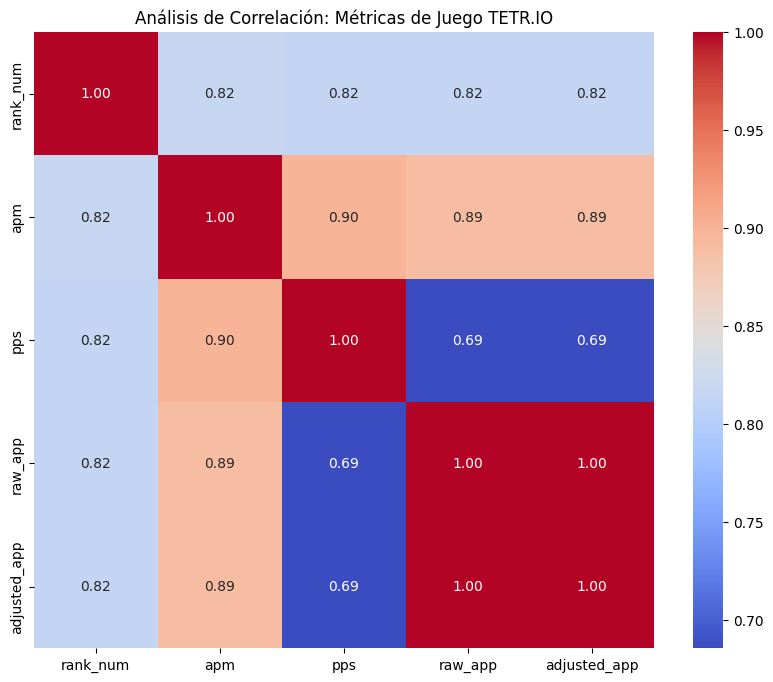

In [14]:
plt.figure(figsize=(10, 8))
# Usamos df_final porque ya está limpio y con los tipos de datos correctos
matriz_corr = df_final.corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Análisis de Correlación: Métricas de Juego TETR.IO')
plt.show()

## 7. Distribución por Rango

Esta sección visualiza la distribución de los jugadores a través de los diferentes rangos después de haber sido mapeados a valores numéricos.

*   Se utiliza un gráfico de barras para mostrar la frecuencia de cada `rank_num`.
*   Esto ayuda a entender la composición de la base de jugadores en términos de sus rangos.

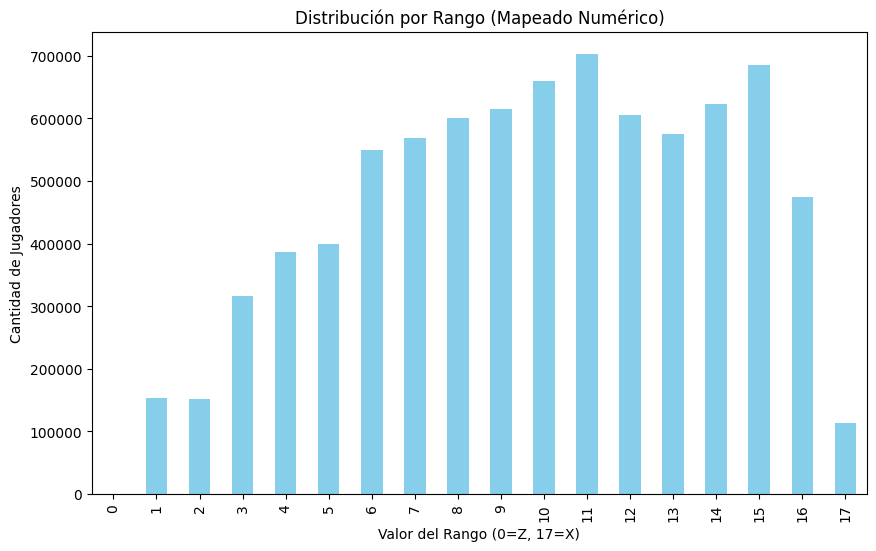

In [15]:
# 7. GRÁFICO DE BARRAS (Distribución por Rango)
# Esto confirmará que el mapeo ya no es solo 0.0
plt.figure(figsize=(10, 6))
df_final['rank_num'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribución por Rango (Mapeado Numérico)')
plt.xlabel('Valor del Rango (0=Z, 17=X)')
plt.ylabel('Cantidad de Jugadores')
plt.show()

## 8. Relación entre APM y Rango (Gráfico de Dispersión)

Este gráfico de dispersión muestra la relación entre los Ataques por Minuto (APM) y el `rank_num` (rango numérico de los jugadores). Esto nos permite observar si existe una tendencia de APM más altos en rangos superiores (números de rango más altos).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


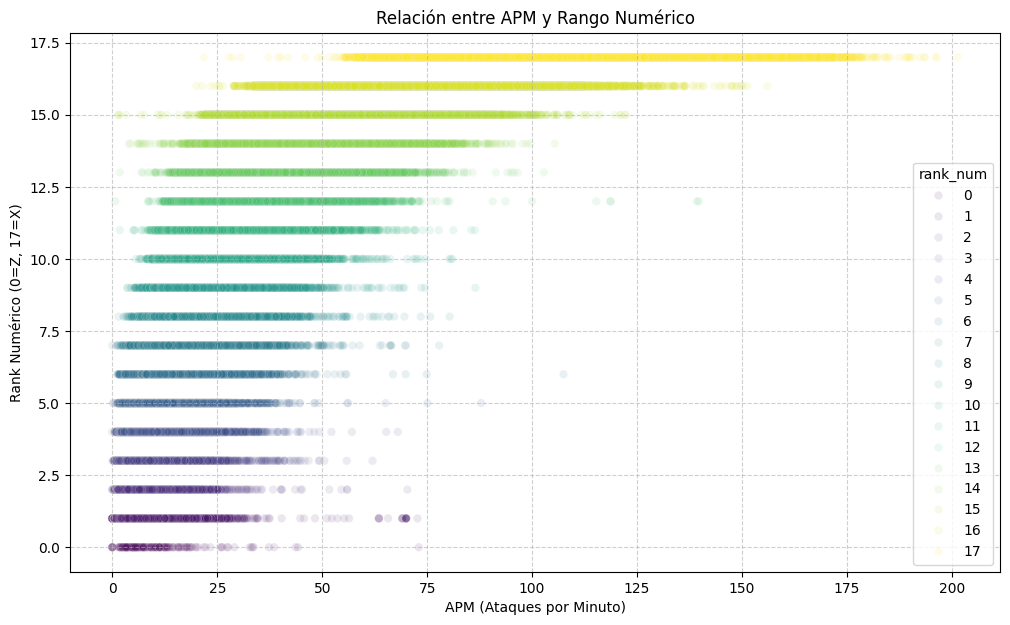

In [16]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='apm', y='rank_num', data=df_final, alpha=0.1, hue='rank_num', palette='viridis', legend='full')
plt.title('Relación entre APM y Rango Numérico')
plt.xlabel('APM (Ataques por Minuto)')
plt.ylabel('Rank Numérico (0=Z, 17=X)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()